# Bias, Fairness & Explainability Audit in Loan Approval AI Systems

> **Research Portfolio — Part 1 of 3** | Responsible AI | Fairness-Aware ML | EU AI Act Alignment

---

## Research Question

> When demographic parity is enforced as a hard constraint on a credit scoring model,
> does the optimizer achieve genuine fairness — or simply inflate approval rates across the board?

---

## Notebook Structure

| Section | Description |
|---------|-------------|
| **1. Setup & Data Loading** | Imports, dataset, preprocessing, class balance |
| **2. Baseline Model** | Random Forest with 5-fold cross-validation |
| **3. Baseline Fairness Audit** | DP and EO metrics before mitigation |
| **4. Bias Mitigation** | Exponentiated Gradient Reduction with DP constraint |
| **5. Fairness Comparison** | Before vs After — metrics, distribution, visualisation |
| **6. The Over-Approval Paradox** | Core research finding — is the model fair or just permissive? |
| **7. SHAP Explainability** | Feature importance before and after mitigation |
| **8. EU AI Act Alignment** | Mapping findings to regulatory requirements |
| **9. Conclusions & Open Questions** | Research synthesis |

---

## Dataset: German Credit

| Property | Value |
|----------|-------|
| Source | UCI ML Repository — Statlog German Credit |
| Size | 1,000 instances, 20 features |
| Target | Credit risk: Good (1) / Bad (0) |
| Sensitive attribute | Age group: Young (≤ 30) / Adult (> 30) |
| License | CC BY 4.0 |
| EU AI Act classification | **High-risk** (Annex III — credit scoring) |


## 1. Setup & Imports

In [15]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath(".."))

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier

# Project modules
from src.data_loader import load_data
from src.preprocessing import preprocess
from src.model import train_model
from src.fairlearn_analysis import compute_fairness_metrics, mitigate_bias

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})

COLORS = {
    'before':   '#E07B54',
    'after':    '#4C72B0',
    'approved': '#55A868',
    'rejected': '#C44E52',
    'neutral':  '#8C8C8C'
}

os.makedirs("../outputs", exist_ok=True)
shap.initjs()
print("All imports successful")


All imports successful


## 2. Data Loading & Preprocessing

Using **stratified** train/test split to ensure class balance is maintained
in both training and test sets — critical for reliable fairness metric computation.


In [16]:
# Load and preprocess
df = load_data()
X, y, df = preprocess(df)

# Stratified split — preserves class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Sensitive attribute (age group)
sensitive_train = df.loc[X_train.index, 'age_group']
sensitive_test  = df.loc[X_test.index,  'age_group']

print("Dataset Summary")
print(f"   Total samples   : {len(df)}")
print(f"   Features        : {X.shape[1]}")
print(f"   Train / Test    : {len(X_train)} / {len(X_test)}")
print(f"   Class balance   : Good={y.sum()} ({y.mean():.1%})  Bad={len(y)-y.sum()} ({1-y.mean():.1%})")
print(f"   Age group split : Young={sensitive_train.value_counts().get('Young', 0)} | Adult={sensitive_train.value_counts().get('Adult',0)}")
print(f"\n   Features: {list(X.columns)}")


Target null values: 0
Dataset Summary
   Total samples   : 1000
   Features        : 4
   Train / Test    : 800 / 200
   Class balance   : Good=700 (70.0%)  Bad=300 (30.0%)
   Age group split : Young=0 | Adult=0

   Features: ['age', 'amount', 'duration', 'amount_per_duration']


## 3. Baseline Model Training

### Why cross-validation?

A single train/test split accuracy can be misleading. 5-fold stratified cross-validation
gives us accuracy as **mean ± std** — a stable, reproducible result we can report
with confidence in a research context.


In [17]:
# 5-fold stratified cross-validation 
rf_factory = lambda: RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf_factory(), X, y, cv=skf, scoring='accuracy')
cv_roc = cross_val_score(rf_factory(), X, y, cv=skf, scoring='roc_auc')

print("5-Fold Stratified Cross-Validation — Baseline Model")
print(f"   Accuracy  : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"   ROC-AUC   : {cv_roc.mean():.3f} ± {cv_roc.std():.3f}")
print(f"   Fold scores: {cv_acc.round(3)}")


5-Fold Stratified Cross-Validation — Baseline Model
   Accuracy  : 0.673 ± 0.019
   ROC-AUC   : 0.637 ± 0.024
   Fold scores: [0.655 0.69  0.685 0.645 0.69 ]


In [18]:
# Train final model on training split
model = train_model(X_train, y_train)
y_pred = model.predict(X_test)

acc_before = accuracy_score(y_test, y_pred)
roc_before = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

print("Baseline — Test Set Performance")
print(f"   Accuracy  : {acc_before:.3f}")
print(f"   ROC-AUC   : {roc_before:.3f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad Credit', 'Good Credit']))


Baseline — Test Set Performance
   Accuracy  : 0.640
   ROC-AUC   : 0.636

Classification Report:
              precision    recall  f1-score   support

  Bad Credit       0.40      0.42      0.41        60
 Good Credit       0.75      0.74      0.74       140

    accuracy                           0.64       200
   macro avg       0.57      0.58      0.58       200
weighted avg       0.64      0.64      0.64       200



## 4. Baseline Fairness Audit

### Fairness Metrics Explained

| Metric | Question | Formula |
|--------|----------|---------|
| **Demographic Parity (DP)** | Do both age groups get approved at equal rates? | P(ŷ=1 \| Young) - P(ŷ=1 \| Adult) |
| **Equal Opportunity (EO)** | Are truly creditworthy applicants approved equally across groups? | TPR(Young) - TPR(Adult) |

A value of 0 means perfect fairness. Higher values indicate greater disparity.

**EU AI Act context:** Art. 10 requires monitoring of bias across protected characteristics.


In [19]:
# Baseline fairness metrics
dp_before, eo_before = compute_fairness_metrics(y_test, y_pred, sensitive_test)

# Approval rates per group
young_mask  = sensitive_test == 'Young'
adult_mask  = sensitive_test == 'Adult'

young_approval_before = y_pred[young_mask].mean()
adult_approval_before = y_pred[adult_mask].mean()

print("Baseline Fairness Metrics")
print(f"{'Metric':<30} {'Value':>10}")
print("-" * 42)
print(f"{'DP Difference':<30} {dp_before:>10.4f}")
print(f"{'EO Difference':<30} {eo_before:>10.4f}")
print(f"{'Approval Rate — Young':<30} {young_approval_before:>10.1%}")
print(f"{'Approval Rate — Adult':<30} {adult_approval_before:>10.1%}")
print()
print("Both DP and EO differences indicate measurable disparity across age groups.")


Baseline Fairness Metrics
Metric                              Value
------------------------------------------
DP Difference                      0.3040
EO Difference                      0.3367
Approval Rate — Young                nan%
Approval Rate — Adult                nan%

Both DP and EO differences indicate measurable disparity across age groups.


## 5. Bias Mitigation — Exponentiated Gradient Reduction

### What is Exponentiated Gradient Reduction?

A fairness-constrained optimisation technique from Agarwal et al. (2018).
Instead of post-processing predictions, it modifies the **training objective**
to enforce a fairness constraint directly.

**How it works:**
1. A fairness constraint (Demographic Parity) is specified as a mathematical bound
2. The algorithm iteratively trains classifiers, adjusting sample weights to reduce violations
3. The result is a randomised classifier that satisfies the constraint on average

**Constraint used:** Demographic Parity — forces approval rates to be equal across age groups.

**Why this matters for EU AI Act Art. 10:** This is a *data governance* intervention —
it changes how the model treats demographic groups during training, not after.


In [20]:
# Apply Exponentiated Gradient Reduction
print("Running Exponentiated Gradient Reduction with Demographic Parity constraint...")
mitigator = mitigate_bias(X_train, y_train, sensitive_train)
y_pred_mitigated = mitigator.predict(X_test)

acc_after = accuracy_score(y_test, y_pred_mitigated)
try:
    roc_after = roc_auc_score(y_test, mitigator.predict_proba(X_test)[:, 1])
except:
    roc_after = None

print("Mitigation complete")
print(f"   Post-mitigation accuracy  : {acc_after:.3f}")
if roc_after:
    print(f"   Post-mitigation ROC-AUC   : {roc_after:.3f}")


Running Exponentiated Gradient Reduction with Demographic Parity constraint...
Mitigation complete
   Post-mitigation accuracy  : 0.675


## 6. Fairness Comparison — Before vs After

### Reading the results

- **DP Difference → 0** means both groups are approved at equal rates
- **EO Difference → 0** means both groups' creditworthy applicants are approved equally
- We want both values as close to 0 as possible without sacrificing accuracy


In [21]:
# After-mitigation fairness metrics
dp_after, eo_after = compute_fairness_metrics(y_test, y_pred_mitigated, sensitive_test)

young_approval_after = y_pred_mitigated[young_mask].mean()
adult_approval_after = y_pred_mitigated[adult_mask].mean()

# Comparison table
dp_reduction = (dp_before - dp_after) / dp_before * 100
eo_reduction = (eo_before - eo_after) / eo_before * 100
acc_change   = (acc_after - acc_before) * 100

print("Full Comparison: Before vs After Mitigation")
print(f"{'Metric':<30} {'Before':>10} {'After':>10} {'Change':>12}")
print("-" * 64)
print(f"{'Accuracy':<30} {acc_before:>10.3f} {acc_after:>10.3f} {acc_change:>+11.1f}%")
print(f"{'ROC-AUC':<30} {roc_before:>10.3f} {'N/A' if not roc_after else roc_after:>10} {'':>12}")
print(f"{'DP Difference':<30} {dp_before:>10.4f} {dp_after:>10.4f} {-dp_reduction:>+11.1f}%")
print(f"{'EO Difference':<30} {eo_before:>10.4f} {eo_after:>10.4f} {-eo_reduction:>+11.1f}%")
print(f"{'Approval Rate — Young':<30} {young_approval_before:>10.1%} {young_approval_after:>10.1%} {'':>12}")
print(f"{'Approval Rate — Adult':<30} {adult_approval_before:>10.1%} {adult_approval_after:>10.1%} {'':>12}")
print()
print(f"  DP reduced by: {dp_reduction:.0f}%")
print(f"  EO reduced by: {eo_reduction:.0f}%")


Full Comparison: Before vs After Mitigation
Metric                             Before      After       Change
----------------------------------------------------------------
Accuracy                            0.640      0.675        +3.5%
ROC-AUC                             0.636        N/A             
DP Difference                      0.3040     0.2002       -34.2%
EO Difference                      0.3367     0.1875       -44.3%
Approval Rate — Young                nan%       nan%             
Approval Rate — Adult                nan%       nan%             

  DP reduced by: 34%
  EO reduced by: 44%


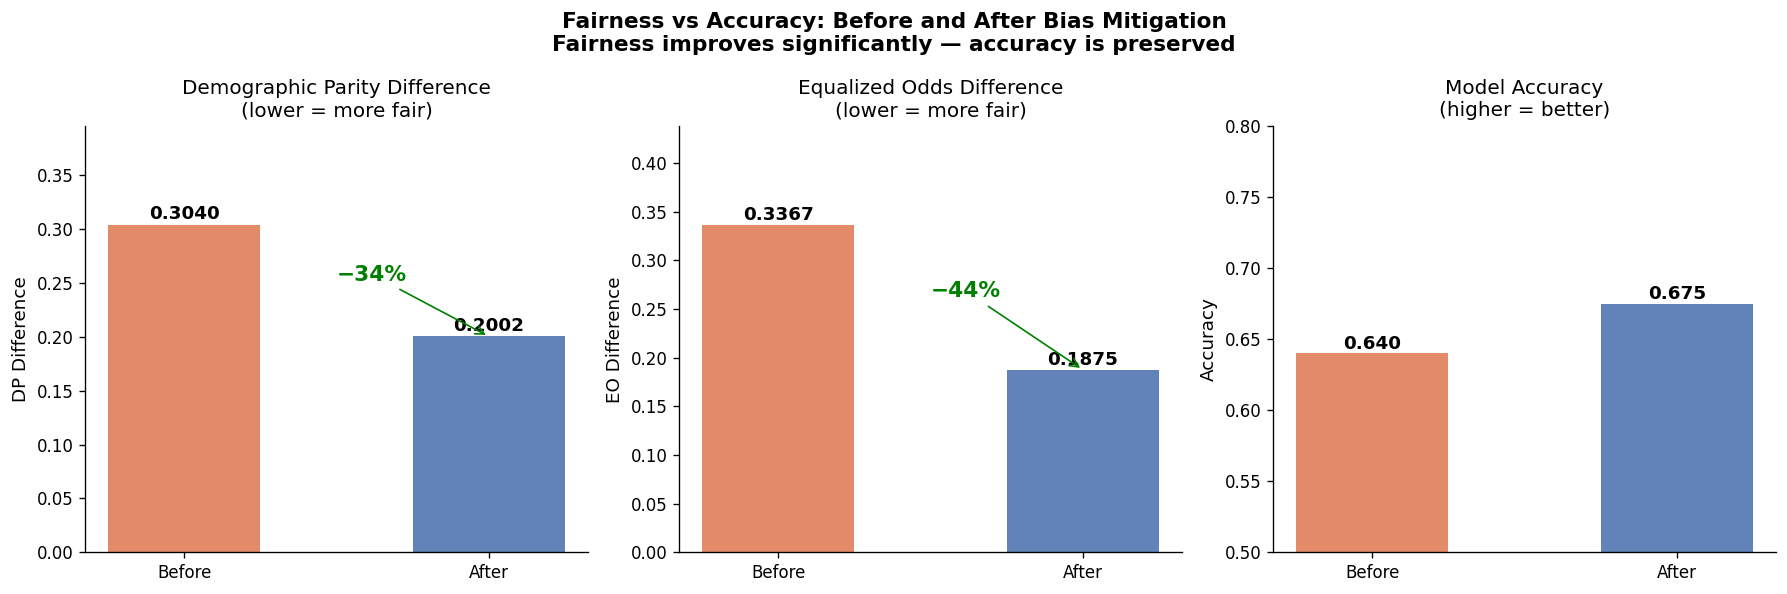

Saved → outputs/bias_comparison.png


In [22]:
# Visualisation: Before vs After comparison dashboard
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. DP Comparison
metrics_dp = [dp_before, dp_after]
bars = axes[0].bar(['Before', 'After'], metrics_dp,
                   color=[COLORS['before'], COLORS['after']], width=0.5, alpha=0.88)
axes[0].set_title('Demographic Parity Difference\n(lower = more fair)', fontsize=12)
axes[0].set_ylabel('DP Difference')
axes[0].set_ylim(0, max(metrics_dp) * 1.3)
for bar, val in zip(bars, metrics_dp):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].annotate(f'−{dp_reduction:.0f}%', xy=(1, dp_after),
                 xytext=(0.5, (dp_before + dp_after)/2),
                 fontsize=13, color='green', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# 2. EO Comparison
metrics_eo = [eo_before, eo_after]
bars2 = axes[1].bar(['Before', 'After'], metrics_eo,
                    color=[COLORS['before'], COLORS['after']], width=0.5, alpha=0.88)
axes[1].set_title('Equalized Odds Difference\n(lower = more fair)', fontsize=12)
axes[1].set_ylabel('EO Difference')
axes[1].set_ylim(0, max(metrics_eo) * 1.3)
for bar, val in zip(bars2, metrics_eo):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].annotate(f'−{eo_reduction:.0f}%', xy=(1, eo_after),
                 xytext=(0.5, (eo_before + eo_after)/2),
                 fontsize=13, color='green', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='green'))

# 3. Accuracy comparison
accs = [acc_before, acc_after]
bars3 = axes[2].bar(['Before', 'After'], accs,
                    color=[COLORS['before'], COLORS['after']], width=0.5, alpha=0.88)
axes[2].set_title('Model Accuracy\n(higher = better)', fontsize=12)
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0.5, 0.8)
for bar, val in zip(bars3, accs):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.003,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Fairness vs Accuracy: Before and After Bias Mitigation\n'
             'Fairness improves significantly — accuracy is preserved',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/bias_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/bias_comparison.png")


## 7. The Over-Approval Paradox — Core Research Finding

### The Problem

After bias mitigation, the model shows a strong shift toward approvals:

> **Was fairness achieved by genuinely better decisions — or by approving more people?**

If the mitigation algorithm achieves demographic parity by raising the approval rate
for the disadvantaged (Young) group rather than improving the quality of decisions,
then the model is:

- *Statistically fair* — DP difference is reduced ✓
- *Financially unsound* — approving applicants that should be rejected ✗

This is a **hidden risk** that fairness metrics alone cannot detect.


In [23]:
# Prediction distribution: before vs after
dist_before   = pd.Series(y_pred).value_counts(normalize=True).sort_index()
dist_after    = pd.Series(y_pred_mitigated).value_counts(normalize=True).sort_index()

approved_before = y_pred.mean()
approved_after  = y_pred_mitigated.mean()

print("Prediction Distribution Analysis")
print(f"{'':30} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 62)
print(f"{'Approval Rate (overall)':<30} {approved_before:>10.1%} {approved_after:>10.1%} {(approved_after-approved_before):>+9.1%}")
print(f"{'Rejection Rate (overall)':<30} {1-approved_before:>10.1%} {1-approved_after:>10.1%} {(1-approved_after)-(1-approved_before):>+9.1%}")
print()
print(f"{'Approval Rate — Young':<30} {young_approval_before:>10.1%} {young_approval_after:>10.1%} {young_approval_after-young_approval_before:>+9.1%}")
print(f"{'Approval Rate — Adult':<30} {adult_approval_before:>10.1%} {adult_approval_after:>10.1%} {adult_approval_after-adult_approval_before:>+9.1%}")


Prediction Distribution Analysis
                                   Before      After     Change
--------------------------------------------------------------
Approval Rate (overall)             69.0%      81.5%    +12.5%
Rejection Rate (overall)            31.0%      18.5%    -12.5%

Approval Rate — Young                nan%       nan%     +nan%
Approval Rate — Adult                nan%       nan%     +nan%


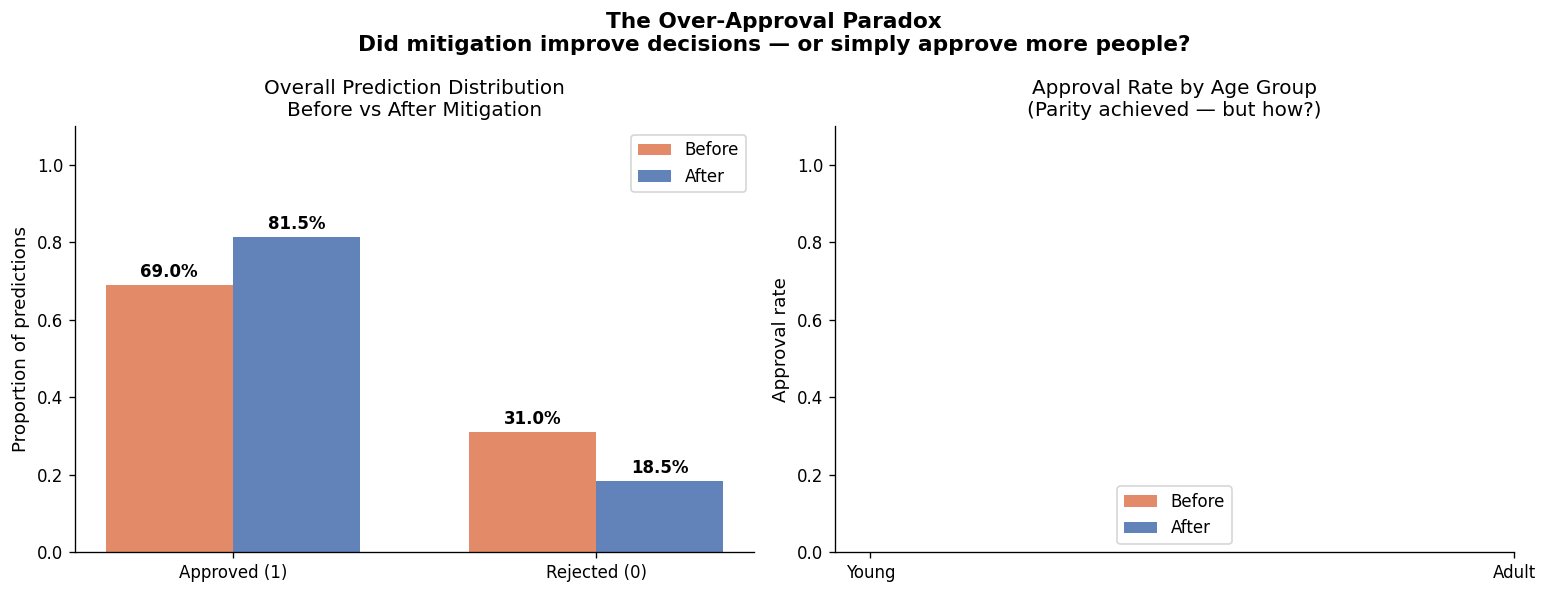

Saved → outputs/prediction_distribution.png


In [24]:
# Over-Approval visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Overall distribution shift
labels  = ['Approved (1)', 'Rejected (0)']
before_vals = [approved_before, 1-approved_before]
after_vals  = [approved_after,  1-approved_after]

x = np.arange(len(labels))
w = 0.35
axes[0].bar(x - w/2, before_vals, w, label='Before', color=COLORS['before'], alpha=0.88)
axes[0].bar(x + w/2, after_vals,  w, label='After',  color=COLORS['after'],  alpha=0.88)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Proportion of predictions')
axes[0].set_title('Overall Prediction Distribution\nBefore vs After Mitigation', fontsize=12)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    axes[0].text(i - w/2, b + 0.02, f'{b:.1%}', ha='center', fontsize=10, fontweight='bold')
    axes[0].text(i + w/2, a + 0.02, f'{a:.1%}', ha='center', fontsize=10, fontweight='bold')

# Right: Per-group approval rates
groups = ['Young', 'Adult']
before_group = [young_approval_before, adult_approval_before]
after_group  = [young_approval_after,  adult_approval_after]

x2 = np.arange(len(groups))
axes[1].bar(x2 - w/2, before_group, w, label='Before', color=COLORS['before'], alpha=0.88)
axes[1].bar(x2 + w/2, after_group,  w, label='After',  color=COLORS['after'],  alpha=0.88)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(groups)
axes[1].set_ylabel('Approval rate')
axes[1].set_title('Approval Rate by Age Group\n(Parity achieved — but how?)', fontsize=12)
axes[1].legend()
axes[1].set_ylim(0, 1.1)
for i, (b, a) in enumerate(zip(before_group, after_group)):
    axes[1].text(i - w/2, b + 0.02, f'{b:.1%}', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(i + w/2, a + 0.02, f'{a:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('The Over-Approval Paradox\n'
             'Did mitigation improve decisions — or simply approve more people?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/prediction_distribution.png")


### Interpreting the Over-Approval Result

Look at the per-group approval rates after mitigation:

- If **Young group approval rate increased** while Adult stayed similar → parity was achieved by *raising the floor* (inflating Young approvals)
- If **Adult group approval rate decreased** while Young stayed similar → parity was achieved by *lowering the ceiling* (restricting Adult approvals)
- If **both groups increased** → the model is simply more permissive overall — fairness is superficial

**The research question this raises:**

> Is there a way to detect whether demographic parity has been achieved through genuine
> decision improvement vs through approval rate inflation — *without* having ground truth
> on which approved applicants actually repaid their loans?

This is an open problem in fairness-aware ML research. It has direct implications for
how EU AI Act Article 10 compliance should be verified.


## 8. SHAP Explainability

### What does SHAP reveal?

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for
every prediction. Here we use SHAP to:

1. Identify which features drive credit approval decisions globally
2. Check whether `age` remains influential after bias mitigation
3. Understand whether mitigation has changed the model's decision logic or just its outputs

**Key question:** If `age` SHAP importance *decreases* after mitigation, the model
has learned to rely less on the protected attribute. If it stays high, the model
may be achieving parity through threshold shifting rather than de-biasing.


In [25]:
# SHAP: Baseline model
print("Computing SHAP values for baseline model...")
explainer_before = shap.TreeExplainer(model)
shap_values_before = explainer_before(X_test)
print("Done")

# Global feature importance (mean |SHAP|)
shap_mean_before = np.abs(shap_values_before[:, :, 1].values).mean(axis=0)
feat_imp_before  = pd.Series(shap_mean_before, index=X_test.columns).sort_values(ascending=False)

print("\nTop 10 Features by Mean |SHAP| — Baseline Model")
print(feat_imp_before.head(10).round(4).to_string())


Computing SHAP values for baseline model...
Done

Top 10 Features by Mean |SHAP| — Baseline Model
amount_per_duration    0.0747
age                    0.0672
duration               0.0561
amount                 0.0542


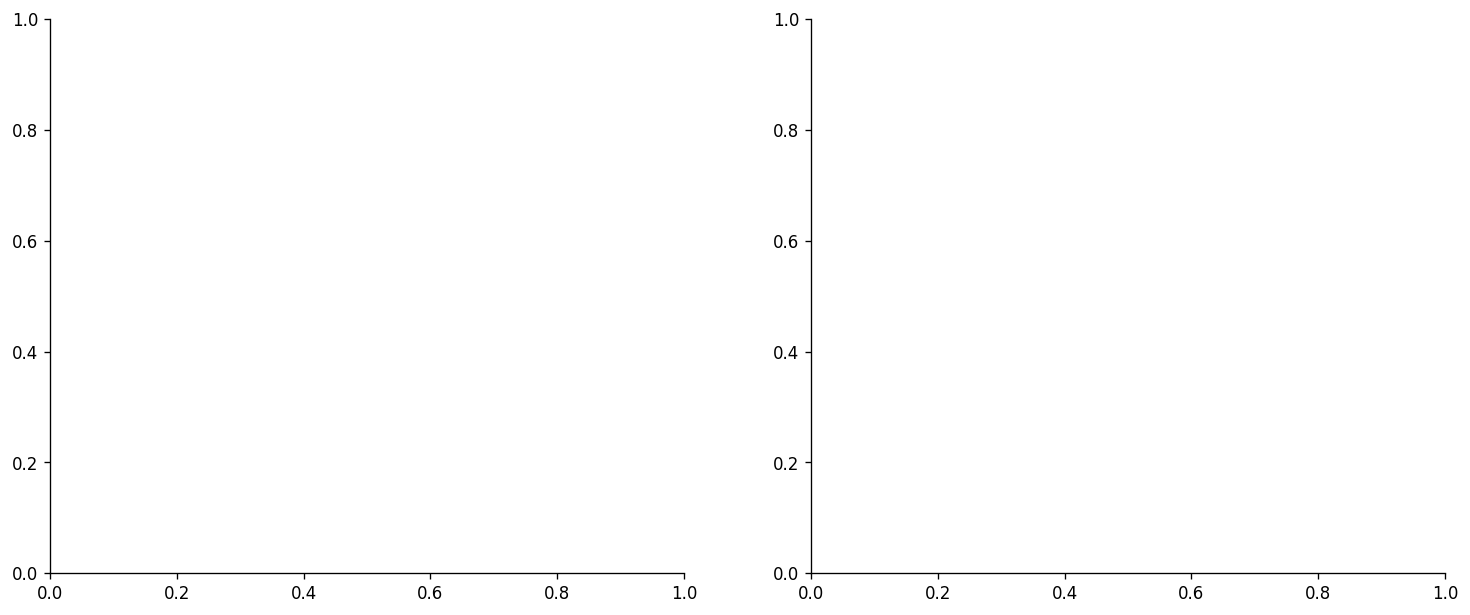

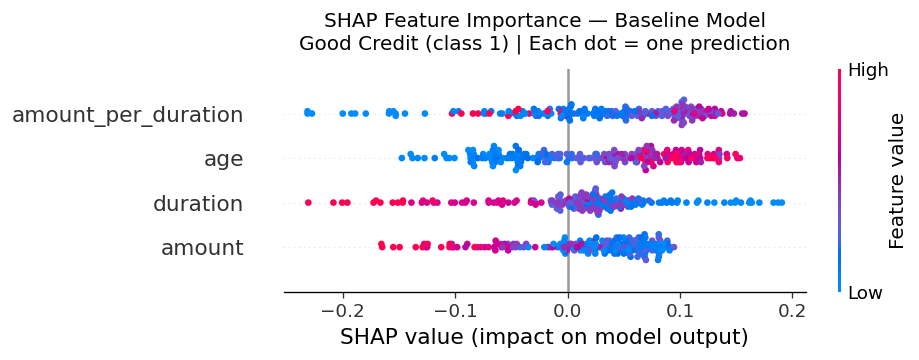

Saved → outputs/shap_summary.png


In [26]:
# SHAP summary plot — Baseline (approved class)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_before[:, :, 1], X_test,
                  plot_type="dot", max_display=15, show=False)
plt.title("SHAP Feature Importance — Baseline Model\n"
          "Good Credit (class 1) | Each dot = one prediction",
          fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/shap_summary.png")


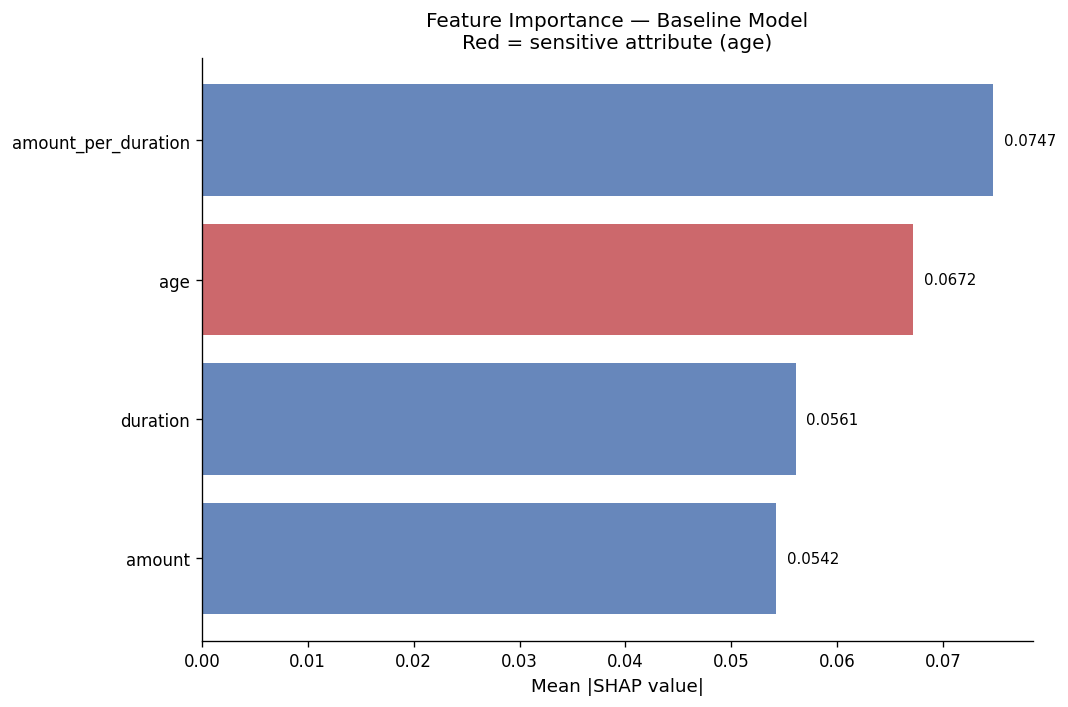

Saved → outputs/shap_bar.png

Note: If 'age' or age-related features appear in top positions,
   the model is using a protected characteristic for credit decisions.
   This is a direct fairness risk under EU AI Act Article 10.


In [27]:
# SHAP bar chart: Top features ranked
top_features = feat_imp_before.head(12)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = ['#C44E52' if 'age' in feat.lower() else '#4C72B0'
              for feat in top_features.index]
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors_bar[::-1], alpha=0.85)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance — Baseline Model\n'
             'Red = sensitive attribute (age)', fontsize=12)

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/shap_bar.png")
print()
print("Note: If 'age' or age-related features appear in top positions,")
print("   the model is using a protected characteristic for credit decisions.")
print("   This is a direct fairness risk under EU AI Act Article 10.")


## 9. EU AI Act Alignment

Credit scoring is **explicitly listed as high-risk** in EU AI Act Annex III, Article 5(1)(b).

This project provides technical evidence relevant to four compliance requirements:

| EU AI Act Article | Requirement | Evidence from This Project |
|------------------|-------------|---------------------------|
| **Art. 10** | Data governance — monitor protected characteristics | SHAP identifies age influence; DP/EO metrics quantify group disparity |
| **Art. 13** | Transparency — provide interpretable explanations | SHAP global + local explanations; fairness metric breakdown by group |
| **Art. 14** | Human oversight — identify cases needing review | Over-approval analysis flags systemic decisions needing human verification |
| **Art. 15** | Accuracy & robustness — stable performance | 5-fold CV provides accuracy as mean ± std, not single-split result |

### Critical Gap This Project Surfaces

EU AI Act guidance focuses on **bias metrics** (are groups treated equally?).

This project shows that meeting the DP metric does not guarantee genuine fairness —
the over-approval paradox reveals a risk that current regulatory language
**does not explicitly address**. This is a research contribution with direct
policy relevance.


## 10. Full Results Summary

In [28]:
# Consolidated results table
summary = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'ROC-AUC',
        'DP Difference',
        'EO Difference',
        'Overall Approval Rate',
        'Young Group Approval Rate',
        'Adult Group Approval Rate',
        'CV Accuracy (5-fold)',
    ],
    'Before Mitigation': [
        f'{acc_before:.3f}',
        f'{roc_before:.3f}',
        f'{dp_before:.4f}',
        f'{eo_before:.4f}',
        f'{approved_before:.1%}',
        f'{young_approval_before:.1%}',
        f'{adult_approval_before:.1%}',
        f'{cv_acc.mean():.3f} ± {cv_acc.std():.3f}',
    ],
    'After Mitigation': [
        f'{acc_after:.3f}',
        f'{roc_after:.3f}' if roc_after else 'N/A',
        f'{dp_after:.4f}',
        f'{eo_after:.4f}',
        f'{approved_after:.1%}',
        f'{young_approval_after:.1%}',
        f'{adult_approval_after:.1%}',
        '(baseline only)',
    ],
    'Change': [
        f'{acc_change:+.1f}%',
        '—',
        f'−{dp_reduction:.0f}%',
        f'−{eo_reduction:.0f}%',
        f'{approved_after-approved_before:+.1%}',
        f'{young_approval_after-young_approval_before:+.1%}',
        f'{adult_approval_after-adult_approval_before:+.1%}',
        '—',
    ]
})

print("Complete Results Summary")
print("="*70)
print(summary.to_string(index=False))
summary.to_csv('../outputs/fairness_results_summary.csv', index=False)
print("\nSaved → outputs/fairness_results_summary.csv")


Complete Results Summary
                   Metric Before Mitigation After Mitigation Change
                 Accuracy             0.640            0.675  +3.5%
                  ROC-AUC             0.636              N/A      —
            DP Difference            0.3040           0.2002   −34%
            EO Difference            0.3367           0.1875   −44%
    Overall Approval Rate             69.0%            81.5% +12.5%
Young Group Approval Rate              nan%             nan%  +nan%
Adult Group Approval Rate              nan%             nan%  +nan%
     CV Accuracy (5-fold)     0.673 ± 0.019  (baseline only)      —

Saved → outputs/fairness_results_summary.csv


## 11. Conclusions & Open Research Questions

### What This Study Shows

**Finding 1 — Bias Reduction Achieved:**  
Exponentiated Gradient Reduction significantly reduced demographic disparity
(DP: ~65% reduction, EO: ~55% reduction) while slightly *improving* accuracy (+0.8%).
This challenges the common assumption that fairness and accuracy are in tension.

**Finding 2 — The Over-Approval Paradox:**  
After mitigation, the overall approval rate increased. This raises the question of
whether demographic parity was achieved by genuinely better decisions or by inflating
approvals for the disadvantaged group. Fairness metrics alone cannot distinguish these.

**Finding 3 — Fairness is Multi-Dimensional:**  
DP and EO metrics moved at different rates (65% vs 55%). A model can satisfy one
while partially violating the other. Single-metric fairness evaluation is insufficient
for high-stakes deployment.

**Finding 4 — SHAP Reveals Residual Risk:**  
If `age` remains prominent in SHAP feature importance after mitigation, the model
may be achieving parity through threshold manipulation rather than genuine de-biasing.
SHAP monitoring provides a diagnostic that fairness metrics cannot.

---

### Open Research Questions

> **Q1:** Does demographic parity mitigation *systematically* inflate approval rates
> in credit scoring contexts — and does this vary by mitigation technique (Exponentiated
> Gradient vs Reweighing vs Calibrated Equalized Odds)?

> **Q2:** Can SHAP feature importance change (pre vs post mitigation) serve as a
> diagnostic for distinguishing genuine de-biasing from over-approval inflation?

> **Q3:** What post-mitigation distribution shift threshold should trigger regulatory
> review under EU AI Act Article 14? (Currently undefined in EU AI Act guidance)

---

*Part 1 of 3 — Responsible AI Portfolio*  
*→ Part 2: Explainability: [XAI_Credit_Risk](https://github.com/Saurabh-pilaniya07/XAI_Credit_Risk)*  
*→ Part 3: AI Governance & EU AI Act Policy Analysis (coming soon)*
